In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
#criação de um dicionário para os dados

data = {
    "Name": ["New York", "São Paulo", "Tokyo", "Lagos", "Sydney"],
    "Population": [8419600, 12325232, 13929286, 1500000, 5312163],
    "Latitude": [40.7128, -23.5505, 35.6895, 6.5244, -33.8688],
    "Longitude": [-74.0060, -46.6333, 139.6917, 3.3792, 151.2093]
}

In [3]:
type(data)

dict

In [5]:
cities_df = pd.DataFrame(data)

cities_df

,Name,Population,Latitude,Longitude
0,New York,8419600,40.7128,-74.0060
1,São Paulo,12325232,-23.5505,-46.6333
2,Tokyo,13929286,35.6895,139.6917
3,Lagos,1500000,6.5244,3.3792
4,Sydney,5312163,-33.8688,151.2093


## GeoDataFrames anda GeoSeries

In [ ]:
#comando para o dataframe do geopandas
#poderia ter a variável z, mas não existe nesse caso

gdf = gpd.GeoDataFrame(
    cities_df,
    geometry = gpd.points_from_xy(
        cities_df['Longitude'],
        cities_df['Latitude']
    )
)

gdf

,Name,Population,Latitude,Longitude,geometry
0,New York,8419600,40.7128,-74.0060,POINT (-74.006 40.7128)
1,São Paulo,12325232,-23.5505,-46.6333,POINT (-46.6333 -23.5505)
2,Tokyo,13929286,35.6895,139.6917,POINT (139.6917 35.6895)
3,Lagos,1500000,6.5244,3.3792,POINT (3.3792 6.5244)
4,Sydney,5312163,-33.8688,151.2093,POINT (151.2093 -33.8688)


In [7]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Name        5 non-null      str     
 1   Population  5 non-null      int64   
 2   Latitude    5 non-null      float64 
 3   Longitude   5 non-null      float64 
 4   geometry    5 non-null      geometry
dtypes: float64(2), geometry(1), int64(1), str(1)
memory usage: 332.0 bytes


In [ ]:
#cria a series com os dados geográficos

gdf.geometry

0      POINT (-74.006 40.7128)
1    POINT (-46.6333 -23.5505)
2     POINT (139.6917 35.6895)
3        POINT (3.3792 6.5244)
4    POINT (151.2093 -33.8688)
Name: geometry, dtype: geometry

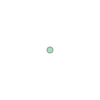

In [ ]:
#indexação igual ao pandas/dict
#esse ponto surgiu por conta da biblioteca shapely -> from shapely import Point
#geopandas depende da shapely pra funcionar -> biblioteca de mais baixo nível

gdf['geometry'][0]

## Polygons


In [10]:
wisconsin = 'POLYGON((-90.6303 42.5116, -87.0241 42.4954, -87.1477 43.3721, -87.1230 43.6838, -86.9911 44.1694, -86.8579 44.4828, -90.6303 42.5116))'

In [11]:
data = {
    "Name": ["Wisconsin"],
    "Population": [5911000],
    "geometry": [wisconsin]
}

In [12]:
gdf =gpd.GeoDataFrame(data)

In [13]:
gdf.head()

,Name,Population,geometry
0,Wisconsin,5911000,"POLYGON((-90.6303 42.5116, -87.0241 42.4954, -..."


In [14]:
#transformar em um polígono 

gdf = gpd.GeoDataFrame(data, geometry = gpd.GeoSeries.from_wkt(data['geometry']))

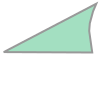

In [16]:
gdf['geometry'][0]